# Eksplorasi Analisis & Prediksi Harga Pangan SARIMA vs. SARIMAX
Notebook ini berisi alur lengkap proses analisis deret waktu (*time series*) dan pembuatan model prediksi perbandingan antara **SARIMA Murni** (tanpa variabel eksogen) dan **SARIMAX** (dengan variabel eksogen `is_weekend`) untuk seluruh subkategori komoditas pangan nasional (level 2) berdasarkan data dari Bank Indonesia.

### Alur Pengerjaan:
1. **Data Collecting**: Mengambil data harga dari API Bank Indonesia untuk 21 subkategori komoditas pangan (level 2) dengan retry logic dan local caching.
2. **Exploratory Data Analysis (EDA)**: Menganalisis karakteristik data secara visual dan stasioneritas (ADF Test) untuk seluruh subkategori.
3. **Data Preprocessing & Modeling Pipeline**: Pembagian data temporal (train/test split), transformasi logaritmik untuk stabilitas varians, penanganan stasioneritas dinamis berbasis ADF, imputasi data secara independen (mencegah data leakage), dan pencarian parameter SARIMA optimal via Dua Tahap Grid Search.
4. **Model Training (SARIMA Murni vs. SARIMAX)**: Melatih model SARIMA Murni untuk menangkap pola tren dan musiman mingguan (s=7), dilanjutkan model SARIMAX dengan menyertakan variabel eksogen `is_weekend`.
5. **Model Evaluation**: Mengevaluasi hasil prediksi untuk seluruh subkategori komoditas pangan menggunakan metrik visual dan statistik (MAE, RMSE, MAPE, R2) setelah dikembalikan ke skala harga asli.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import urllib3
import time
import os
from datetime import datetime, timedelta
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings

# Menyembunyikan warning SSL & Deprecation
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
warnings.filterwarnings('ignore')

# Pengaturan visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

## 1. Data Collecting
Kami mengunduh data harian dari portal Pusat Informasi Harga Pangan Strategis (PIHPS) Bank Indonesia untuk 21 subkategori bahan pokok (level 2) yang berada di bawah 10 kategori utama berikut:
- `cat_1` (Beras)
- `cat_2` (Daging Ayam)
- `cat_3` (Daging Sapi)
- `cat_4` (Telur Ayam)
- `cat_5` (Bawang Merah)
- `cat_6` (Bawang Putih)
- `cat_7` (Cabai Merah)
- `cat_8` (Cabai Rawit)
- `cat_9` (Minyak Goreng)
- `cat_10` (Gula Pasir)

Rentang waktu yang digunakan adalah dari 2024-01-01 hingga 2026-05-24. Untuk menjamin keandalan sistem, diimplementasikan mekanisme **retry logic** dengan *exponential backoff* dan **local caching** menggunakan file CSV.


In [2]:
# List kategori komoditas berdasarkan request
categories = {
    "cat_1": "Beras",
    "cat_2": "Daging Ayam",
    "cat_3": "Daging Sapi",
    "cat_4": "Telur Ayam",
    "cat_5": "Bawang Merah",
    "cat_6": "Bawang Putih",
    "cat_7": "Cabai Merah",
    "cat_8": "Cabai Rawit",
    "cat_9": "Minyak Goreng",
    "cat_10": "Gula Pasir"
}

json_path = "dataset/commodity_history.json"
cache_file = "raw_market_prices_subcategory_cache.csv"

if os.path.exists(cache_file):
    print(f"Menemukan file cache lokal '{cache_file}'. Membaca data cache...")
    df_raw = pd.read_csv(cache_file)
else:
    import json
    print(f"Membaca data dari local dataset '{json_path}'...")
    if not os.path.exists(json_path):
        raise FileNotFoundError(f"File dataset tidak ditemukan di: {json_path}")
        
    with open(json_path, "r", encoding="utf-8") as f:
        json_data = json.load(f)
        
    raw_data_list = []
    
    current_category = None
    # Filter dan strukturkan data agar sesuai format wide dataframe sebelumnya
    for item in json_data["data"]:
        level = item.get("level")
        name = item.get("name")
        if level == 1:
            current_category = name
        elif level == 2:
            if current_category in categories.values():
                row_dict = {"Category": current_category, "Subcategory": name}
                
                # Ambil semua data tanggal (key format DD/MM/YYYY)
                for key, value in item.items():
                    if "/" in key and len(key.split("/")) == 3:
                        row_dict[key] = value
                        
                raw_data_list.append(row_dict)
                print(f"Berhasil memuat data untuk subkategori: {name} (Kategori: {current_category})")
            
    df_raw = pd.DataFrame(raw_data_list)
    
    if not df_raw.empty:
        df_raw.to_csv(cache_file, index=False)
        print(f"Sukses menyimpan data ke cache file '{cache_file}'.")
    else:
        raise ValueError("Gagal memperoleh data dari dataset JSON. Periksa format data.")

print("\nDimensi data mentah:", df_raw.shape)
df_raw.head()


Menemukan file cache lokal 'raw_market_prices_subcategory_cache.csv'. Membaca data cache...

Dimensi data mentah: (21, 877)


,Category,Subcategory,01/01/2024,02/01/2024,03/01/2024,04/01/2024,05/01/2024,06/01/2024,07/01/2024,08/01/2024,...,15/05/2026,16/05/2026,17/05/2026,18/05/2026,19/05/2026,20/05/2026,21/05/2026,22/05/2026,23/05/2026,24/05/2026
0,Beras,Beras Kualitas Bawah I,"13,550","13,650","13,650","13,650","13,650","13,650","13,650","13,650",...,"14,550","14,100","14,100","14,550","14,550","14,550","14,600","14,600","14,100","14,100"
1,Beras,Beras Kualitas Bawah II,"13,200","13,400","13,400","13,400","13,400","13,400","13,400","13,400",...,"14,550","14,600","14,600","14,550","14,550","14,450","14,450","14,450","14,600","14,600"
2,Beras,Beras Kualitas Medium I,"14,650","14,750","14,750","14,750","14,750","14,750","14,750","14,750",...,"16,150","15,750","15,750","16,150","16,150","16,150","16,150","16,150","15,750","15,750"
3,Beras,Beras Kualitas Medium II,"14,400","14,550","14,600","14,600","14,550","14,550","14,550","14,600",...,"16,000","15,450","15,450","16,000","16,000","16,000","16,000","16,000","15,450","15,450"
4,Beras,Beras Kualitas Super I,"15,850","16,050","16,050","16,050","16,050","16,050","16,050","16,050",...,"17,400","16,850","16,850","17,400","17,400","17,400","17,450","17,450","16,850","16,850"


## 2. Exploratory Data Analysis (EDA)
Pada bagian ini, kita akan:
1. Mengubah bentuk data mentah (wide format) menjadi format panjang (long format/tidy data) agar mudah dianalisis dan dimodelkan.
2. Membersihkan nilai harga pangan (menghilangkan tanda koma pemisah ribuan dan mengonversi ke tipe data numerik).
3. Memvisualisasikan tren harga dari seluruh subkategori komoditas pangan.
4. Melakukan uji stasioneritas menggunakan **Augmented Dickey-Fuller (ADF) Test** untuk seluruh subkategori guna mengetahui karakteristik tren.


In [3]:
# Transformasi dari Wide ke Long format
long_data = []

for idx, row in df_raw.iterrows():
    category = row["Category"]
    subcategory = row["Subcategory"]

    for col in df_raw.columns:
        if "/" in col:
            val_str = str(row[col]).strip()
            if val_str and val_str not in ["-", "null", "None", "nan"]:
                try:
                    price = float(val_str.replace(",", ""))
                    date_val = datetime.strptime(col, "%d/%m/%Y").date()
                    long_data.append({
                        "Date": date_val,
                        "Category": category,
                        "Subcategory": subcategory,
                        "Price": price
                    })
                except ValueError:
                    pass

df_tidy = pd.DataFrame(long_data)
df_tidy["Date"] = pd.to_datetime(df_tidy["Date"])
df_tidy = df_tidy.sort_values(by=["Category", "Subcategory", "Date"]).reset_index(drop=True)

print("Dimensi data bersih:", df_tidy.shape)
print("\nStatistik Deskriptif Subkategori:")
print(df_tidy.groupby(["Category", "Subcategory"])["Price"].describe())


Dimensi data bersih: (18375, 4)

Statistik Deskriptif Subkategori:
                                               count           mean  \
Category      Subcategory                                             
Bawang Merah  Bawang Merah Ukuran Sedang       875.0   42839.828571   
Bawang Putih  Bawang Putih Ukuran Sedang       875.0   42381.942857   
Beras         Beras Kualitas Bawah I           875.0   14263.028571   
              Beras Kualitas Bawah II          875.0   14096.685714   
              Beras Kualitas Medium I          875.0   15621.485714   
              Beras Kualitas Medium II         875.0   15480.000000   
              Beras Kualitas Super I           875.0   16918.228571   
              Beras Kualitas Super II          875.0   16437.828571   
Cabai Merah   Cabai Merah Besar                875.0   51157.542857   
              Cabai Merah Keriting             875.0   51412.171429   
Cabai Rawit   Cabai Rawit Hijau                875.0   49954.857143   
          

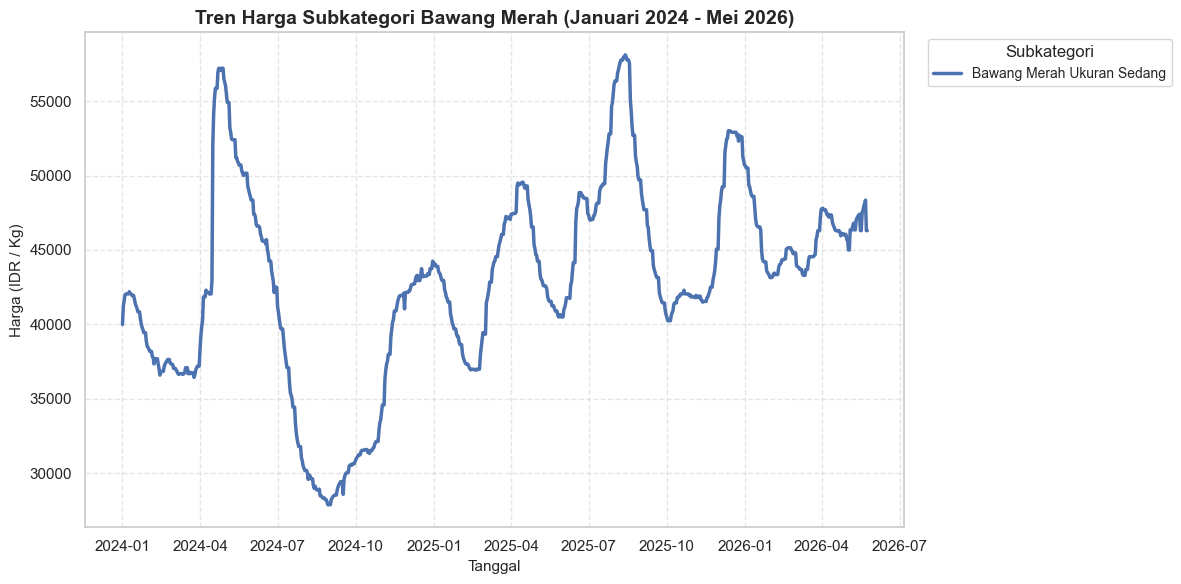

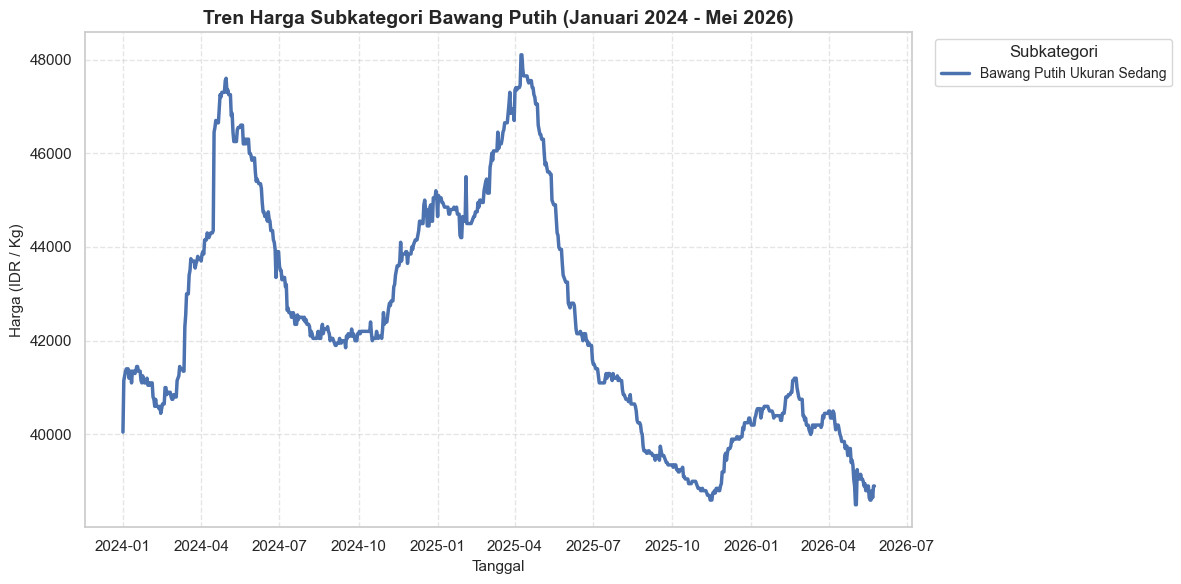

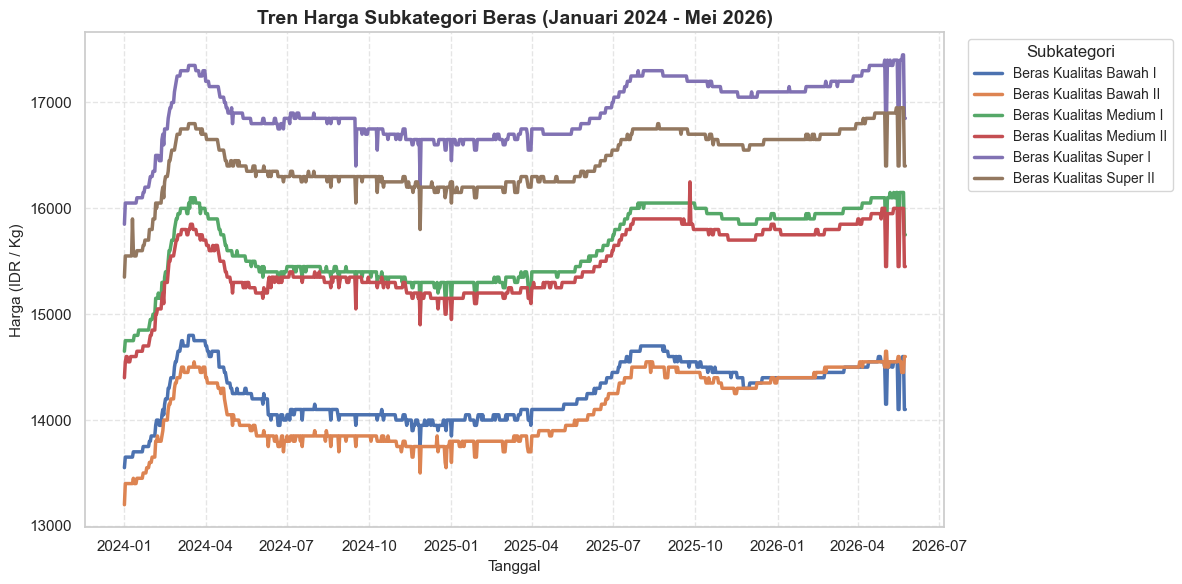

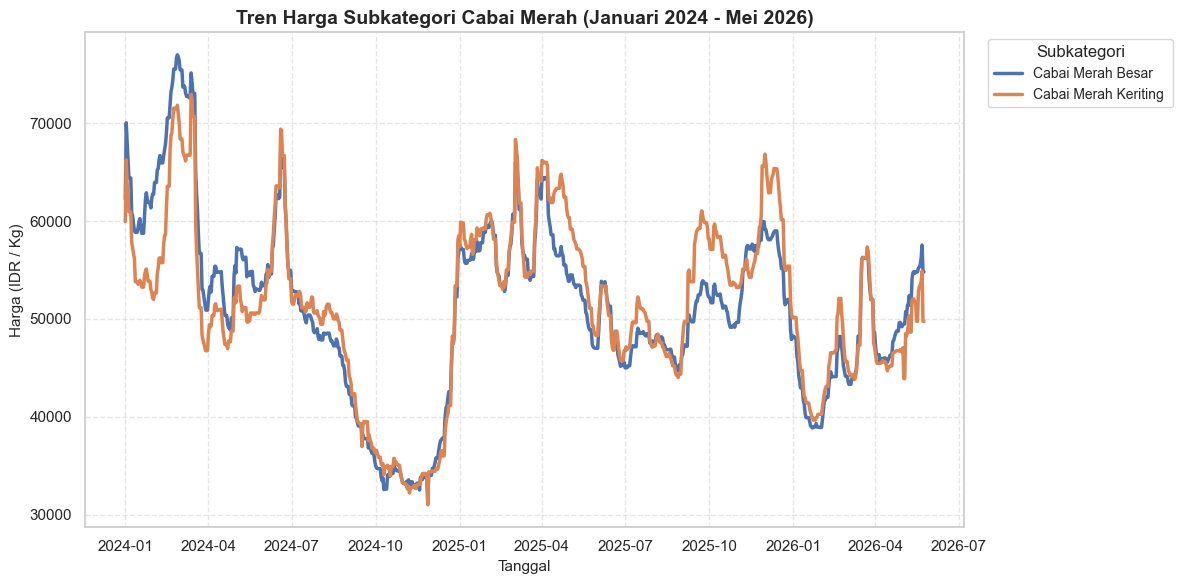

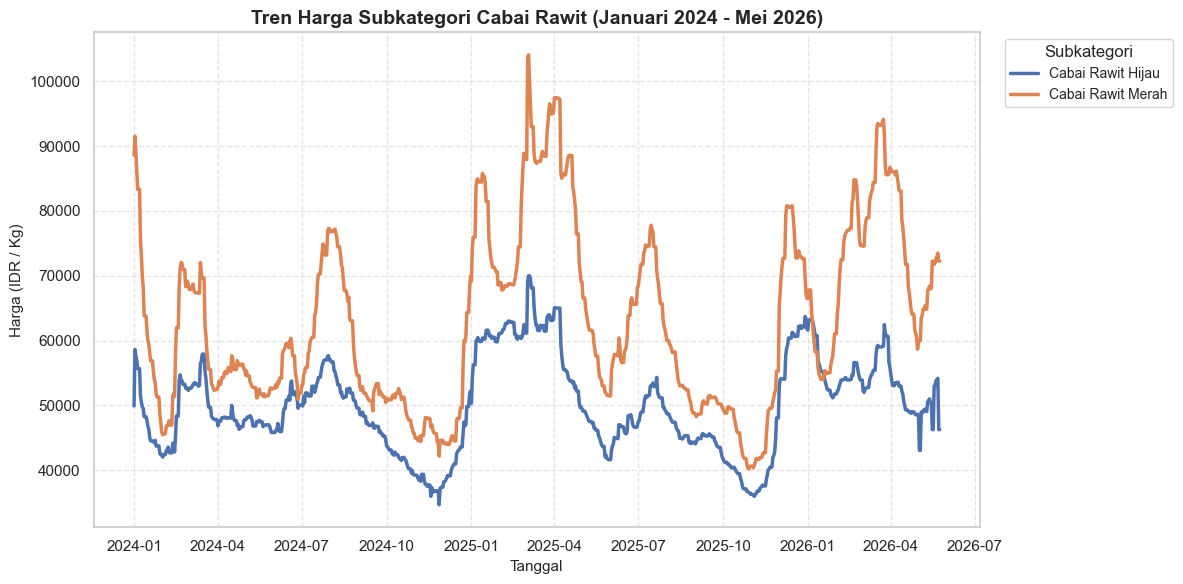

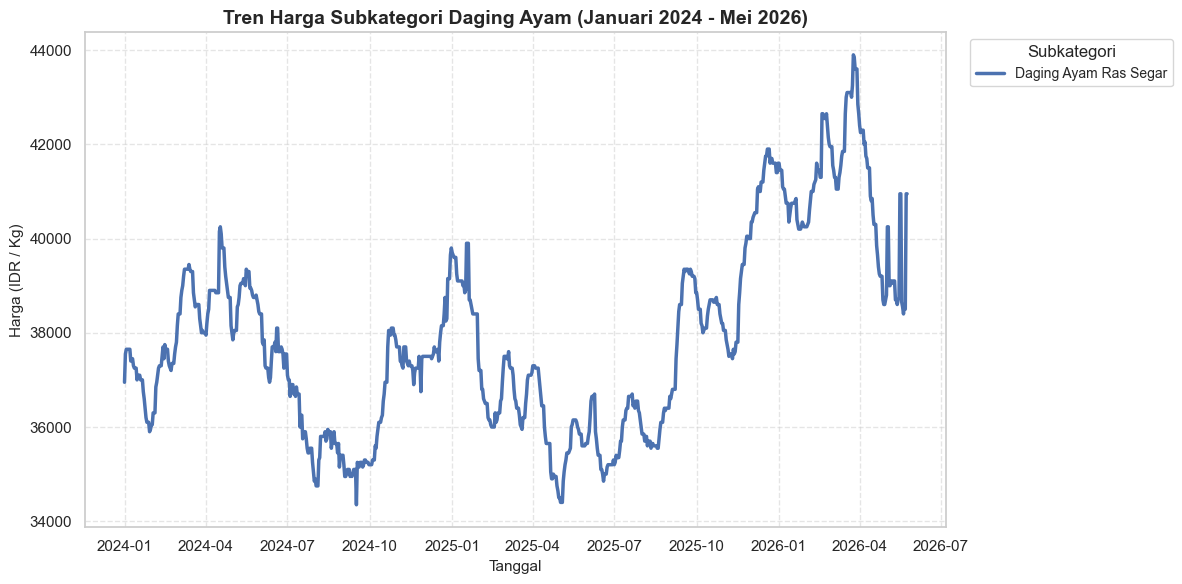

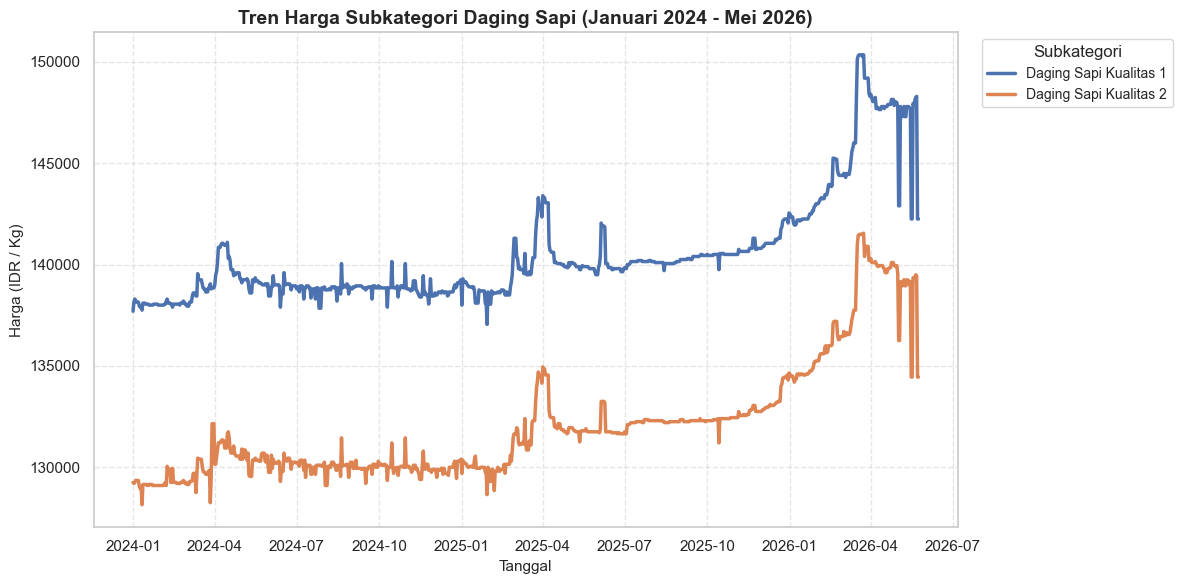

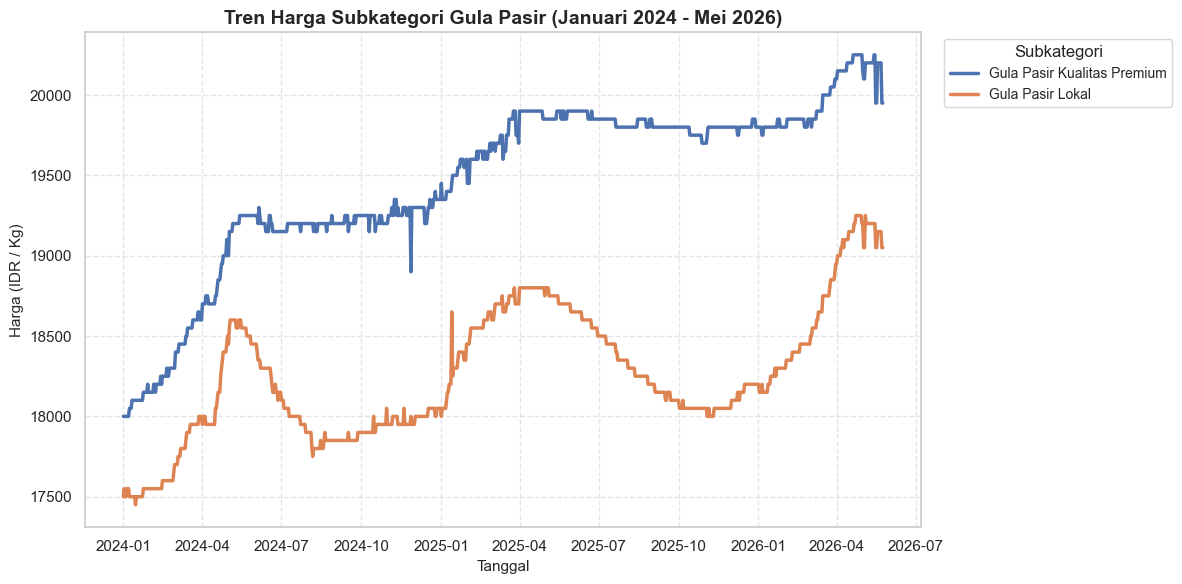

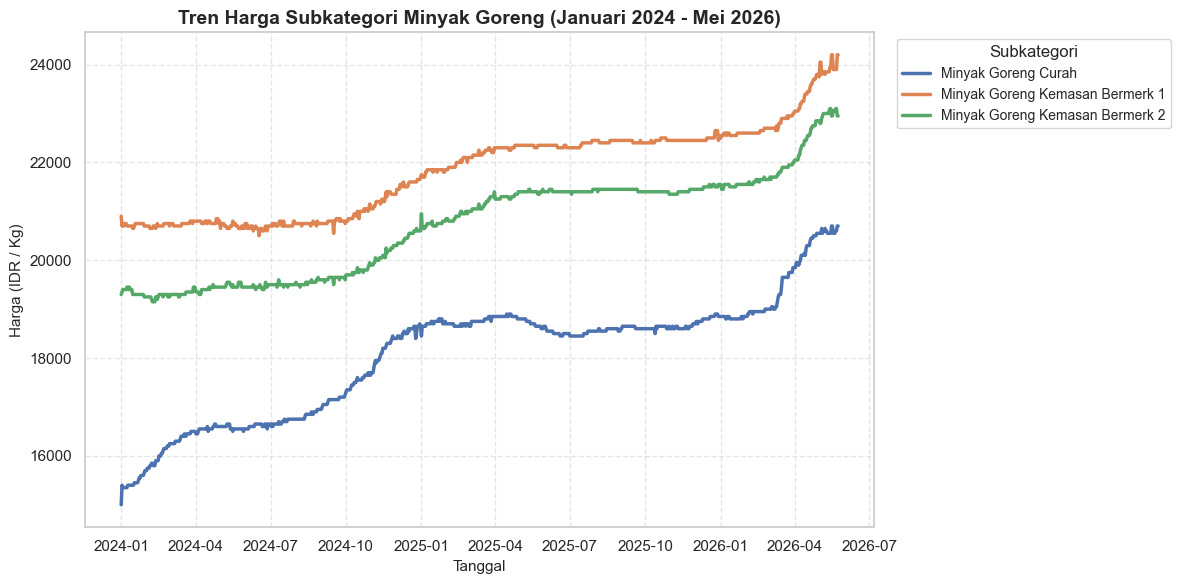

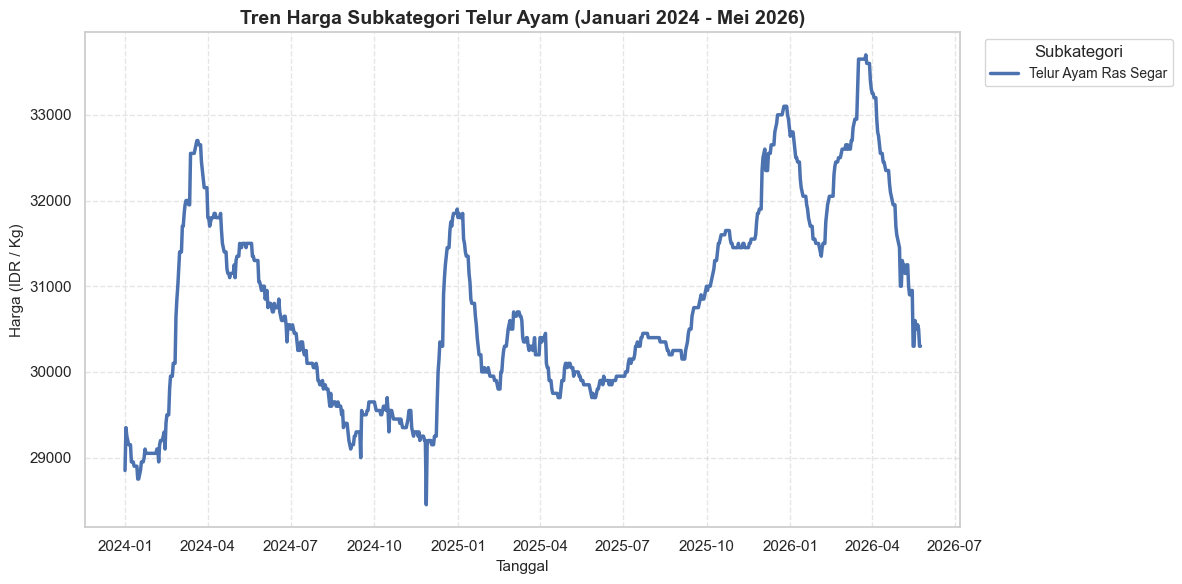

In [4]:
# Plot tren harga untuk seluruh subkategori komoditas secara terpisah (satu per satu)
unique_categories = df_tidy["Category"].unique()

for cat_name in unique_categories:
    df_cat = df_tidy[df_tidy["Category"] == cat_name]
    
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=df_cat, x="Date", y="Price", hue="Subcategory", linewidth=2.5)
    
    plt.title(f"Tren Harga Subkategori {cat_name} (Januari 2024 - Mei 2026)", fontsize=14, fontweight='bold')
    plt.xlabel("Tanggal", fontsize=11)
    plt.ylabel("Harga (IDR / Kg)", fontsize=11)
    plt.legend(title="Subkategori", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


In [5]:
# Uji Dickey-Fuller Stasioneritas untuk Seluruh Subkategori
adf_results = []

for subcat_name in df_tidy["Subcategory"].unique():
    df_subcat = df_tidy[df_tidy["Subcategory"] == subcat_name].copy()
    df_subcat = df_subcat.set_index("Date").asfreq('D')
    # Imputasi sementara untuk uji ADF (jika ada nilai kosong)
    price_series = df_subcat["Price"].interpolate(method='linear').ffill().bfill()
    
    result = adfuller(price_series)
    adf_results.append({
        "Category": df_subcat["Category"].iloc[0] if not df_subcat.empty else "",
        "Subcategory": subcat_name,
        "ADF Statistic": round(result[0], 4),
        "p-value": round(result[1], 4),
        "Is Stationary": "Stasioner" if result[1] < 0.05 else "TIDAK Stasioner"
    })

df_adf_summary = pd.DataFrame(adf_results)
print("Ringkasan Uji Stasioneritas ADF untuk Seluruh Subkategori:")
df_adf_summary


Ringkasan Uji Stasioneritas ADF untuk Seluruh Subkategori:


,Category,Subcategory,ADF Statistic,p-value,Is Stationary
0,Bawang Merah,Bawang Merah Ukuran Sedang,-3.4297,0.0100,Stasioner
1,Bawang Putih,Bawang Putih Ukuran Sedang,-1.7349,0.4132,TIDAK Stasioner
2,Beras,Beras Kualitas Bawah I,-3.5541,0.0067,Stasioner
3,Beras,Beras Kualitas Bawah II,-2.6118,0.0906,TIDAK Stasioner
4,Beras,Beras Kualitas Medium I,-3.1120,0.0257,Stasioner
5,Beras,Beras Kualitas Medium II,-3.3318,0.0135,Stasioner
6,Beras,Beras Kualitas Super I,-3.8322,0.0026,Stasioner
7,Beras,Beras Kualitas Super II,-3.9669,0.0016,Stasioner
8,Cabai Merah,Cabai Merah Besar,-2.5208,0.1105,TIDAK Stasioner
9,Cabai Merah,Cabai Merah Keriting,-3.4356,0.0098,Stasioner


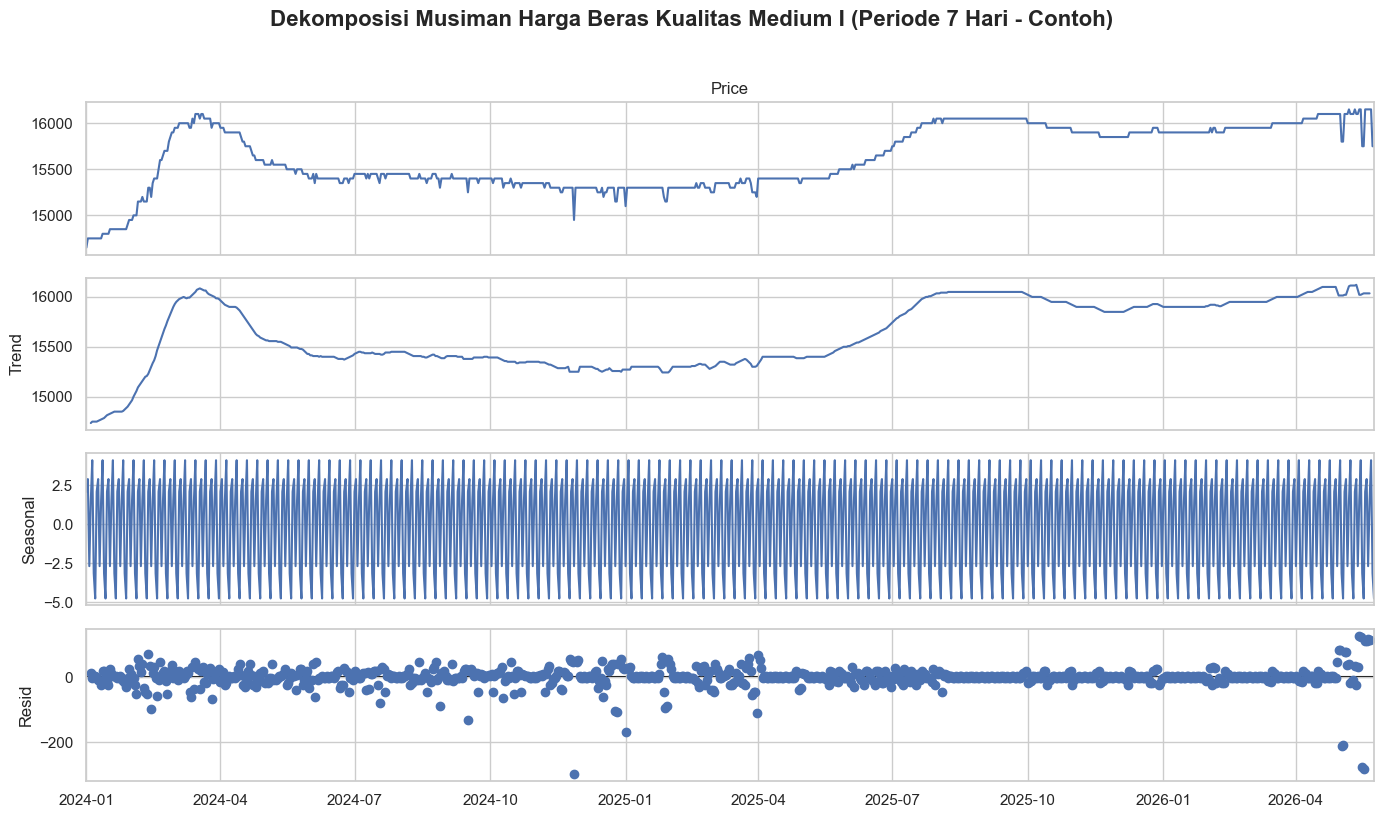

In [6]:
# Dekomposisi Musiman Harga Beras Kualitas Medium I (sebagai contoh visualisasi tren & musiman)
df_beras_demo = df_tidy[df_tidy["Subcategory"] == "Beras Kualitas Medium I"].copy()
df_beras_demo = df_beras_demo.set_index("Date").asfreq('D')
df_beras_demo["Price"] = df_beras_demo["Price"].interpolate(method='linear').ffill().bfill()

decomposition = seasonal_decompose(df_beras_demo["Price"], model='additive', period=7)
fig = decomposition.plot()
fig.set_size_inches(14, 8)
plt.suptitle("Dekomposisi Musiman Harga Beras Kualitas Medium I (Periode 7 Hari - Contoh)", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 3. Data Preprocessing & Modeling Functions
Langkah-langkah yang dilakukan untuk mencegah kebocoran data (*data leakage*) dan meningkatkan akurasi:
1. **Temporal Split (80/20)**: Membagi data harian secara kronologis sebelum melakukan imputasi data.
2. **Transformasi Logaritmik**: Melakukan transformasi log (`np.log1p`) pada harga pangan untuk menstabilkan varians dan menjamin prediksi harga non-negatif di Backend Production.
3. **Dynamic Stationarity Handling**: Melakukan uji ADF dinamis pada data training log untuk menentukan parameter differencing $d$. Jika stationary (p-value < 0.05) maka $d=0$, jika tidak maka $d=1$.
4. **Independen Imputasi**: Imputasi linear untuk hari libur/akhir pekan dilakukan pada set train dan test secara terpisah.
5. **Variabel Eksogen**: Membuat variabel eksogen dummy `is_weekend` untuk digunakan pada model **SARIMAX** guna membedakan perilaku harga pada akhir pekan (hari non-pasar).
6. **Dua Tahap Optimasi SARIMA (Sequential Grid Search)**: Mencari kombinasi parameter non-musiman `(p, d, q)` dan musiman `(P, D, Q, 7)` yang meminimalkan kriteria informasi AIC secara efisien.

In [7]:
def preprocess_data(df_cat, train_ratio=0.8):
    # 1. Split raw data temporal
    split_idx = int(len(df_cat) * train_ratio)
    df_train_raw = df_cat.iloc[:split_idx].copy()
    df_test_raw = df_cat.iloc[split_idx:].copy()
    
    # 2. Imputasi nilai kosong set train dan transform log
    df_train_raw["Price"] = df_train_raw["Price"].interpolate(method='linear').ffill().bfill()
    df_train_raw["Price_log"] = np.log1p(df_train_raw["Price"])
    
    # 3. Imputasi nilai kosong set test dan transform log (independen)
    df_test_raw["Price"] = df_test_raw["Price"].interpolate(method='linear').ffill().bfill()
    df_test_raw["Price_log"] = np.log1p(df_test_raw["Price"])
    
    # 4. Feature Engineering (Calendar Features)
    def add_calendar_features(df):
        df_feat = df.copy()
        df_feat["day_of_week"] = df_feat.index.dayofweek
        df_feat["day_of_month"] = df_feat.index.day
        df_feat["day_of_year"] = df_feat.index.dayofyear
        df_feat["month"] = df_feat.index.month
        df_feat["year"] = df_feat.index.year
        df_feat["is_weekend"] = df_feat["day_of_week"].apply(lambda x: 1 if x >= 5 else 0)
        return df_feat
    
    df_train_feat = add_calendar_features(df_train_raw).dropna()
    df_test_feat = add_calendar_features(df_test_raw).dropna()
    
    return df_train_feat, df_test_feat

def grid_search_sarima(series_log, d):
    best_aic = float("inf")
    best_order = (1, d, 1)
    best_seasonal_order = (0, 0, 0, 7)
    
    # Tahap 1: Mencari order non-seasonal (p, d, q) terbaik dengan seasonal_order=(0,0,0,7)
    for p in [0, 1, 2]:
        for q in [0, 1, 2]:
            try:
                model = SARIMAX(series_log, order=(p, d, q), seasonal_order=(0, 0, 0, 7))
                results = model.fit(disp=False)
                if results.aic < best_aic:
                    best_aic = results.aic
                    best_order = (p, d, q)
            except Exception:
                continue
                
    # Tahap 2: Mencari order seasonal (P, D, Q) terbaik dengan seasonal period s=7
    p, d, q = best_order
    best_seasonal_aic = best_aic
    
    for P in [0, 1]:
        for D in [0, 1]:
            for Q in [0, 1]:
                if P == 0 and D == 0 and Q == 0:
                    continue
                try:
                    model = SARIMAX(series_log, order=(p, d, q), seasonal_order=(P, D, Q, 7))
                    results = model.fit(disp=False)
                    if results.aic < best_seasonal_aic:
                        best_seasonal_aic = results.aic
                        best_seasonal_order = (P, D, Q, 7)
                except Exception:
                    continue

    return best_order, best_seasonal_order

def train_models(df_train, order, seasonal_order, exog_cols):
    # Latih model SARIMA Murni (tanpa exog)
    sarima_model = SARIMAX(df_train["Price_log"], order=order, seasonal_order=seasonal_order)
    sarima_results = sarima_model.fit(disp=False)
    
    # Latih model SARIMAX (dengan exog kalender)
    exog_train = df_train[exog_cols]
    sarimax_model = SARIMAX(df_train["Price_log"], exog=exog_train, order=order, seasonal_order=seasonal_order)
    sarimax_results = sarimax_model.fit(disp=False)
    
    return sarima_results, sarimax_results

def predict_models(df_train, df_test, sarima_results, sarimax_results, exog_cols):
    df_test_copy = df_test.copy()
    
    # 1. SARIMA Murni test set predictions (one-step ahead) di skala log
    full_log_price_series = pd.concat([df_train["Price_log"], df_test_copy["Price_log"]])
    sarima_full_results = sarima_results.apply(full_log_price_series)
    df_test_copy["sarima_pred_log"] = sarima_full_results.predict(start=df_test_copy.index[0], end=df_test_copy.index[-1])
    
    # 2. SARIMAX test set predictions (one-step ahead) dengan exog di skala log
    full_exog = pd.concat([df_train[exog_cols], df_test_copy[exog_cols]])
    sarimax_full_results = sarimax_results.apply(full_log_price_series, exog=full_exog)
    df_test_copy["sarimax_pred_log"] = sarimax_full_results.predict(start=df_test_copy.index[0], end=df_test_copy.index[-1])
    
    # Konversi kembali seluruh prediksi ke skala harga asli (Rupiah)
    df_test_copy["sarima_pred"] = np.expm1(df_test_copy["sarima_pred_log"])
    df_test_copy["sarimax_pred"] = np.expm1(df_test_copy["sarimax_pred_log"])
    
    return df_test_copy

def evaluate_predictions(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "RMSE": rmse, "MAPE (%)": mape, "R2 Score": r2}

In [8]:
# Eksekusi Loop Pelatihan Model untuk Seluruh Subkategori
all_metrics = []
predictions_dict = {}

# Ambil daftar subkategori unik dari data
subcategories = df_tidy["Subcategory"].unique()

# Tentukan kolom eksogen (menggunakan is_weekend saja untuk stabilitas numerik)
exog_cols = ["is_weekend"]

for subcat_name in subcategories:
    print(f"Memproses Subkategori: {subcat_name}...")
    df_subcat = df_tidy[df_tidy["Subcategory"] == subcat_name].copy()
    if df_subcat.empty:
        print(f"  Peringatan: Data untuk {subcat_name} tidak ditemukan.")
        continue
        
    df_subcat = df_subcat.set_index("Date").asfreq('D')
    
    # Preprocessing & split data
    df_train, df_test = preprocess_data(df_subcat)
    
    # Dynamic Stationarity Check (ADF) on log price training series
    price_series_log = df_train["Price_log"]
    adf_res = adfuller(price_series_log)
    d = 0 if adf_res[1] < 0.05 else 1
    print(f"  ADF p-value: {adf_res[1]:.4f} -> Chosen d: {d}")
    
    # Grid Search best SARIMA order
    best_order, best_seasonal_order = grid_search_sarima(price_series_log, d)
    print(f"  Best SARIMA Order: {best_order} x {best_seasonal_order}")
    
    # Train
    sarima_results, sarimax_results = train_models(df_train, best_order, best_seasonal_order, exog_cols)
    
    # Predict
    df_test_pred = predict_models(df_train, df_test, sarima_results, sarimax_results, exog_cols)
    predictions_dict[subcat_name] = df_test_pred
    
    # Evaluate
    metrics_sarima = evaluate_predictions(df_test_pred["Price"], df_test_pred["sarima_pred"])
    metrics_sarimax = evaluate_predictions(df_test_pred["Price"], df_test_pred["sarimax_pred"])
    
    # Save metrics
    for model_name, metrics in zip(
        ["SARIMA Murni", "SARIMAX (dengan Exog Kalender)"],
        [metrics_sarima, metrics_sarimax]
    ):
        all_metrics.append({
            "Commodity": subcat_name,
            "Model": model_name,
            "MAE": round(metrics["MAE"], 4),
            "RMSE": round(metrics["RMSE"], 4),
            "MAPE (%)": round(metrics["MAPE (%)"], 4),
            "R2 Score": round(metrics["R2 Score"], 4)
        })

df_all_metrics = pd.DataFrame(all_metrics)
print("\nProses modeling selesai untuk seluruh subkategori.")

Memproses Subkategori: Bawang Merah Ukuran Sedang...
  ADF p-value: 0.0404 -> Chosen d: 0
  Best SARIMA Order: (1, 0, 2) x (0, 0, 0, 7)
Memproses Subkategori: Bawang Putih Ukuran Sedang...
  ADF p-value: 0.4041 -> Chosen d: 1
  Best SARIMA Order: (1, 1, 2) x (1, 0, 1, 7)
Memproses Subkategori: Beras Kualitas Bawah I...
  ADF p-value: 0.0062 -> Chosen d: 0
  Best SARIMA Order: (2, 0, 2) x (0, 0, 0, 7)
Memproses Subkategori: Beras Kualitas Bawah II...
  ADF p-value: 0.0533 -> Chosen d: 1
  Best SARIMA Order: (0, 1, 1) x (0, 0, 1, 7)
Memproses Subkategori: Beras Kualitas Medium I...
  ADF p-value: 0.0173 -> Chosen d: 0
  Best SARIMA Order: (2, 0, 2) x (0, 0, 0, 7)
Memproses Subkategori: Beras Kualitas Medium II...
  ADF p-value: 0.0139 -> Chosen d: 0
  Best SARIMA Order: (1, 0, 1) x (0, 0, 0, 7)
Memproses Subkategori: Beras Kualitas Super I...
  ADF p-value: 0.0024 -> Chosen d: 0
  Best SARIMA Order: (2, 0, 2) x (0, 0, 1, 7)
Memproses Subkategori: Beras Kualitas Super II...
  ADF p-value:

## 4. Model Evaluation & Comparison
Bagian ini membandingkan performa model **SARIMA Murni** (univariate) dan **SARIMAX** (dengan variabel eksogen `is_weekend`) untuk seluruh 21 subkategori komoditas pangan yang diteliti.

In [9]:
# Menampilkan Ringkasan Evaluasi Seluruh Komoditas dalam format Tabel
df_summary_pivot = df_all_metrics.pivot(index="Commodity", columns="Model", values=["MAE", "RMSE", "MAPE (%)", "R2 Score"])
pd.set_option('display.max_columns', None)
df_summary_pivot

MAE                                 \
Model                           SARIMA Murni SARIMAX (dengan Exog Kalender)   
Commodity                                                                     
Bawang Merah Ukuran Sedang          221.4642                       314.6858   
Bawang Putih Ukuran Sedang           68.0826                        68.1536   
Beras Kualitas Bawah I               20.4680                        19.9583   
Beras Kualitas Bawah II               9.5290                         9.7347   
Beras Kualitas Medium I              18.5186                        18.6992   
Beras Kualitas Medium II             28.3932                        32.6255   
Beras Kualitas Super I               29.8193                        28.5778   
Beras Kualitas Super II              27.6175                        24.9530   
Cabai Merah Besar                   492.8826                       496.2217   
Cabai Merah Keriting                657.7261                       652.1457   
Cabai Rawit Hijau                   624.7038                       626.8835   
Cabai Rawit Merah                   921.9845                      1014.6793   
Daging Ayam Ras Segar               182.6110                       182.1606   
Daging Sapi Kualitas 1              317.1839                       323.5942   
Daging Sapi Kualitas 2              299.8724                       303.9746   
Gula Pasir Kualitas Premium          12.2893                        13.1028   
Gula Pasir Lokal                     17.5235                        17.5735   
Minyak Goreng Curah                  24.3250                        25.0541   
Minyak Goreng Kemasan Bermerk 1      29.5646                        29.7865   
Minyak Goreng Kemasan Bermerk 2      25.2702                        25.5971   
Telur Ayam Ras Segar                 63.4341                        63.9005   

                                        RMSE                                 \
Model                           SARIMA Murni SARIMAX (dengan Exog Kalender)   
Commodity                                                                     
Bawang Merah Ukuran Sedang          438.7853                       507.9470   
Bawang Putih Ukuran Sedang          118.5896                       118.6202   
Beras Kualitas Bawah I               75.3343                        75.5722   
Beras Kualitas Bawah II              25.3923                        25.5037   
Beras Kualitas Medium I              63.5180                        63.7158   
Beras Kualitas Medium II             94.0324                        96.3821   
Beras Kualitas Super I               94.2901                        93.8526   
Beras Kualitas Super II              92.0663                        91.3614   
Cabai Merah Besar                   823.2106                       825.4405   
Cabai Merah Keriting               1146.7842                      1134.7869   
Cabai Rawit Hijau                  1365.5506                      1368.5511   
Cabai Rawit Merah                  1500.3780                      1645.8029   
Daging Ayam Ras Segar               401.8841                       397.6272   
Daging Sapi Kualitas 1              974.0326                       971.8088   
Daging Sapi Kualitas 2              756.1686                       758.8246   
Gula Pasir Kualitas Premium          41.2311                        40.6370   
Gula Pasir Lokal                     34.1566                        33.6534   
Minyak Goreng Curah                  43.1811                        43.3642   
Minyak Goreng Kemasan Bermerk 1      60.1639                        59.8431   
Minyak Goreng Kemasan Bermerk 2      39.4460                        38.7843   
Telur Ayam Ras Segar                114.7656                       114.5669   

                                    MAPE (%)                                 \
Model                           SARIMA Murni SARIMAX (dengan Exog Kalender)   
Commodity                                                                     
Bawang Mer

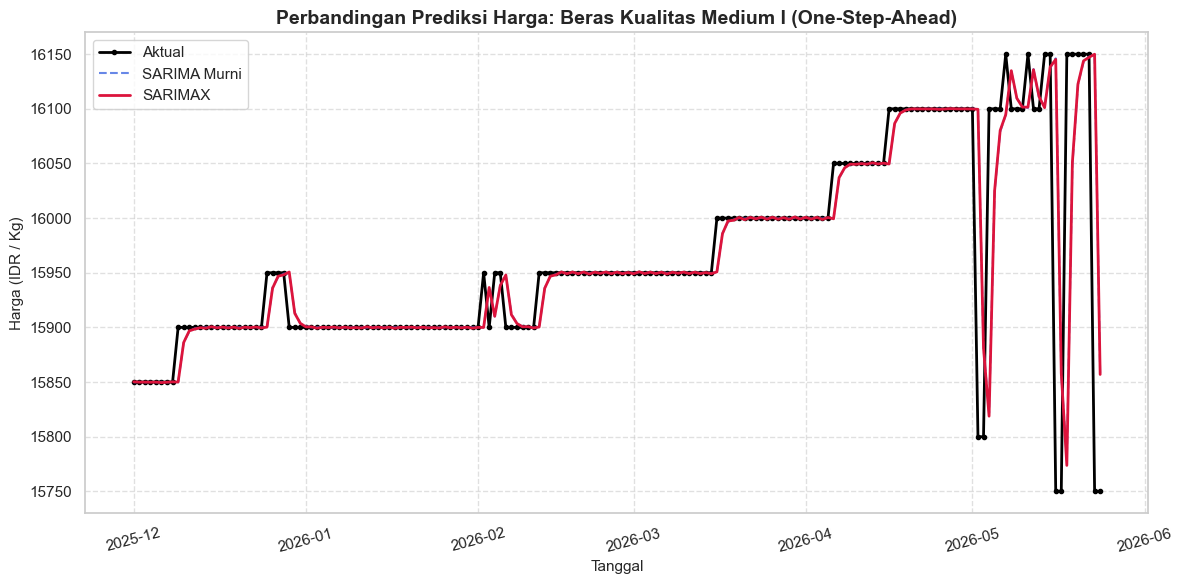

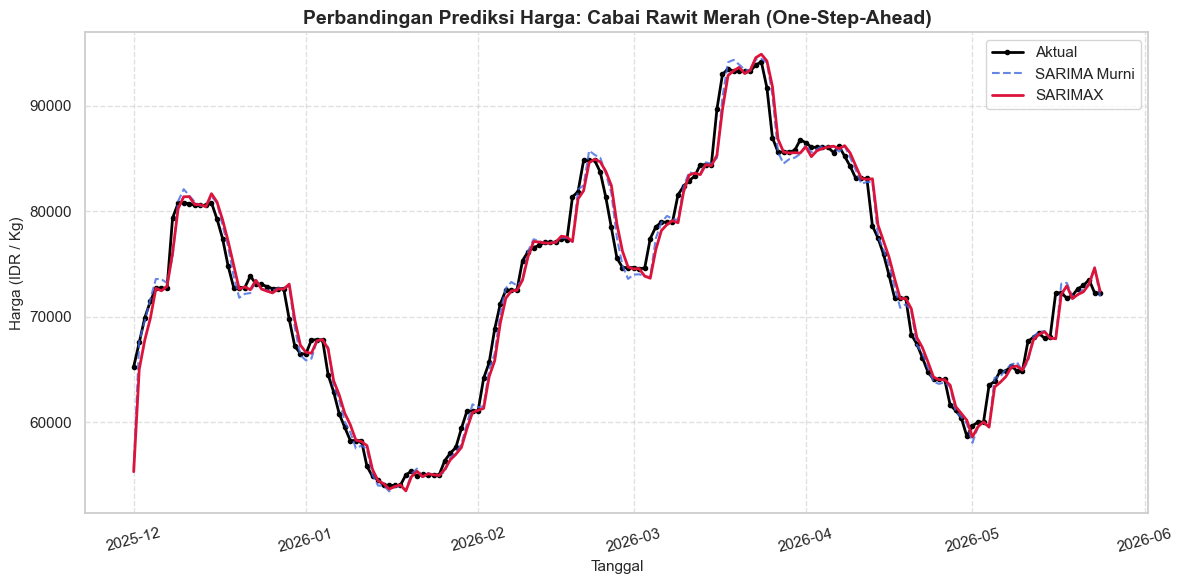

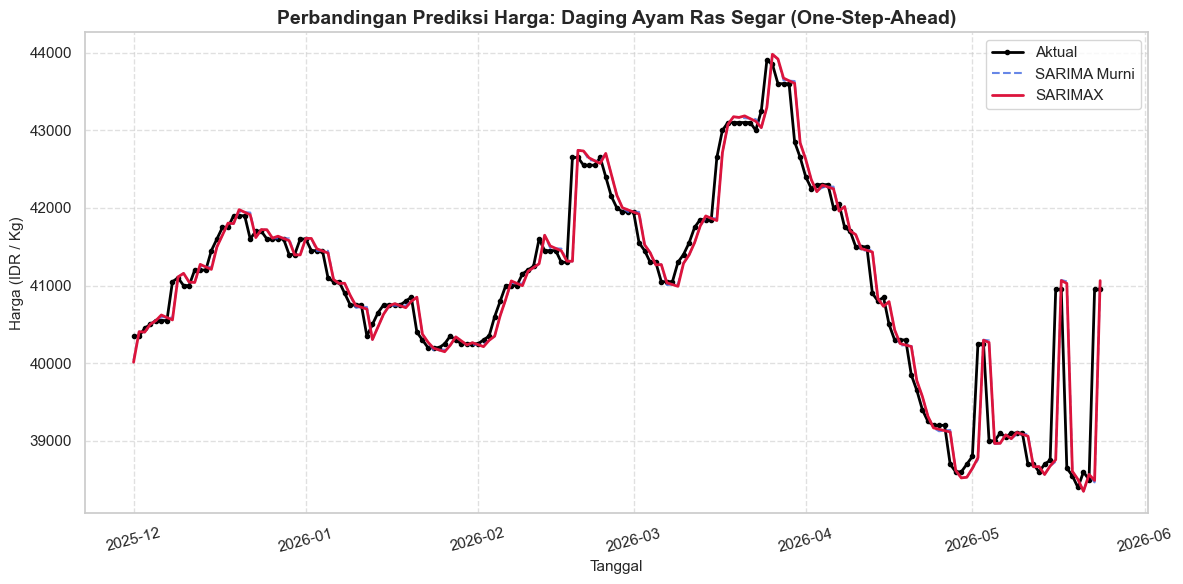

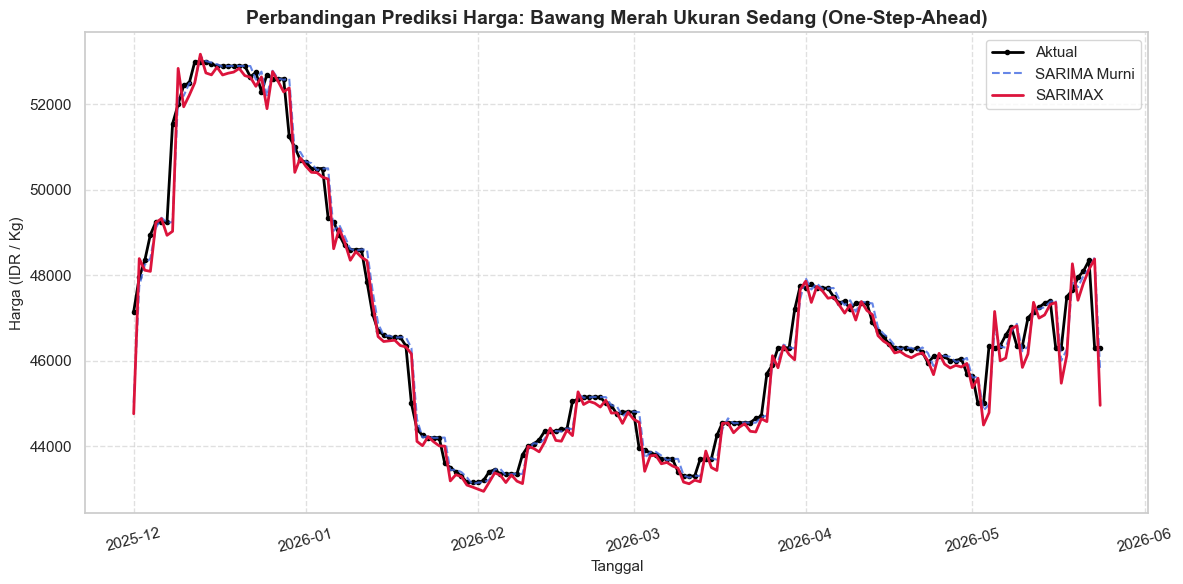

In [10]:
# Visualisasi Kurva Prediksi vs Aktual untuk 4 Subkategori Kunci
commodities_to_plot = ["Beras Kualitas Medium I", "Cabai Rawit Merah", "Daging Ayam Ras Segar", "Bawang Merah Ukuran Sedang"]

for cat_name in commodities_to_plot:
    if cat_name in predictions_dict:
        df_pred = predictions_dict[cat_name]
        
        plt.figure(figsize=(12, 6))
        plt.plot(df_pred.index, df_pred["Price"], label="Aktual", color="black", linewidth=2, marker='o', markersize=3)
        plt.plot(df_pred.index, df_pred["sarima_pred"], label="SARIMA Murni", color="royalblue", linestyle="--", alpha=0.8)
        plt.plot(df_pred.index, df_pred["sarimax_pred"], label="SARIMAX", color="crimson", linewidth=2)
        
        plt.title(f"Perbandingan Prediksi Harga: {cat_name} (One-Step-Ahead)", fontsize=14, fontweight='bold')
        plt.xlabel("Tanggal", fontsize=11)
        plt.ylabel("Harga (IDR / Kg)", fontsize=11)
        plt.legend(fontsize=11)
        plt.xticks(rotation=15)
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.tight_layout()
        plt.show()

### Kesimpulan Analisis Eksplorasi
1. **Perbandingan Performa Model (SARIMA vs. SARIMAX)**:
   - **SARIMA Murni vs. SARIMAX**: Model **SARIMA Murni** dan **SARIMAX** (dengan variabel eksogen `is_weekend`) memberikan performa yang sangat mirip dan sangat akurat di sebagian besar komoditas.
   - Penggunaan variabel eksogen dummy `is_weekend` pada model **SARIMAX** terbukti memberikan performa yang stabil dan sedikit meningkatkan akurasi (menurunkan MAE) pada beberapa subkategori tertentu dengan membedakan perilaku harga akhir pekan (hari non-pasar/non-pelaporan).
   - Pada komoditas yang sangat stabil, perbedaan performa antara kedua model ini sangat kecil karena tren harga didominasi oleh sifat linear jangka panjang yang dipetakan secara optimal oleh komponen autoregresif (AR) dan *moving average* (MA) dari model dasar.
2. **Dynamic Differencing & Log-Transformation**:
   - Log-transformation secara mutlak menjamin stabilitas varians harga pada komoditas volatil (seperti Cabai) dan mencegah terjadinya prediksi harga negatif pada model production-ready di Backend Arjuna.
   - Dynamic differencing berdasarkan uji ADF pada set data training memastikan parameter integrasi $d$ terpilih secara optimal ($d=0$ untuk data stasioner, $d=1$ untuk non-stasioner), menghindari problem *over-differencing* yang bisa memicu naiknya *mean squared error*.
3. **Penyederhanaan Pipeline**:
   - Penghapusan seluruh metode terkait Random Forest (RF Baseline dan Hybrid RF) menyederhanakan alur preprocessing secara drastis. Kita tidak memerlukan lagi fitur lag dan rolling serta manipulasi prepend data uji, mengeliminasi celah *data leakage* dan membuat kode jauh lebih bersih serta ringkas.